# Анализ динамики курсов валют по данным ЦБ РФ

**Итоговый проект по дисциплине "Анализ данных на Python"**

Проект посвящен анализу поведения восьми валют относительно рубля за период с 1 января 2014 года по 12 июня 2026 года. Основной источник данных - официальный XML API Банка России. Для обогащения годовых выводов используются макропоказатели России из World Bank Open Data.



## Исследовательские вопросы

1. Как изменилась стоимость основных валют к рублю с 2014 по 2026 год?
2. Какие валюты были наиболее волатильными и в какие годы происходили основные всплески?
3. Насколько синхронно движутся валюты относительно рубля?
4. Отличается ли волатильность USD/RUB в шоковый период 2022-2023 годов от более спокойного периода 2017-2019 годов?
5. Можно ли объяснить текущий курс USD/RUB через другие валютные курсы и временной тренд?
6. Можно ли выделить группы валют с похожим поведением?

## Проверяемые гипотезы

**H1.** Дневные изменения USD/RUB и EUR/RUB положительно связаны, потому что обе валюты отражают общий спрос на иностранную валюту относительно рубля.

**H2.** Абсолютные дневные изменения USD/RUB в 2022-2023 годах статистически выше, чем в 2017-2019 годах.

**H3.** Курс USD/RUB можно частично объяснить через курсы других валют и временной индекс, но такая модель является объяснительной, а не торговым прогнозом.

## 1. Импорт библиотек и настройки

Используются библиотеки из лекций: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `sklearn`, `statsmodels`.

In [ ]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Подключаем src, чтобы импортировать сборщик данных
sys.path.append(str(PROJECT_ROOT / "src"))

# Задаем единый стиль графиков для всего отчета
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

## 2. Сбор данных

Данные не скачивались вручную CSV-файлом. Сбор автоматизирован в `src/collect_data.py`.

Используются три запроса:

- справочник валют ЦБ РФ: `https://www.cbr.ru/scripts/XML_valFull.asp`;
- исторические курсы по каждой валюте: XML-сервис ЦБ РФ; пример запроса для USD/RUB - `https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01%2F01%2F2014&date_req2=12%2F06%2F2026&VAL_NM_RQ=R01235`;
- макроиндикаторы Всемирного банка; пример запроса по инфляции РФ - `https://api.worldbank.org/v2/country/RUS/indicator/FP.CPI.TOTL.ZG?format=json&per_page=200`.

Для повторной загрузки данных можно переключить `RUN_DATA_COLLECTION = True`.

In [ ]:
from collect_data import main as collect_data

#берем локальные файлы, чтобы не обращаться к API на каждом запуске
RUN_DATA_COLLECTION = False

# Если какого-то файла нет, соберем данные заново
required_files = [
    DATA_RAW / "cbr_currency_rates_raw.csv",
    DATA_RAW / "cbr_currency_dictionary.csv",
    DATA_RAW / "world_bank_macro_raw.csv",
    DATA_PROCESSED / "cbr_currency_rates_processed.csv",
    DATA_PROCESSED / "annual_currency_summary.csv",
    DATA_PROCESSED / "world_bank_macro_processed.csv",
]

if RUN_DATA_COLLECTION or not all(path.exists() for path in required_files):
    # Полный цикл сбора: API, raw-файлы, признаки и годовая сводка
    collect_data()
else:
    print("Локальные данные уже собраны.")

Локальные данные уже собраны. Для обновления включите RUN_DATA_COLLECTION = True.


## 3. Загрузка подготовленных таблиц

Основная таблица - дневные курсы валют. Дополнительно используются справочник валют, годовая агрегация и макропоказатели.

На этом шаге важно убедиться, что данные действительно имеют достаточный объем для анализа: несколько валют, длинный временной период и отдельные таблицы для дневного и годового уровня.

In [3]:
# rates_raw: почти прямой ответ API ЦБ
# rates: таблица для анализа с расчетными признаками
rates_raw = pd.read_csv(DATA_RAW / "cbr_currency_rates_raw.csv", parse_dates=["date"])
rates = pd.read_csv(DATA_PROCESSED / "cbr_currency_rates_processed.csv", parse_dates=["date"])

# annual и macro нужны для выводов на уровне года
annual = pd.read_csv(DATA_PROCESSED / "annual_currency_summary.csv")
macro = pd.read_csv(DATA_PROCESSED / "world_bank_macro_processed.csv")

# Сводка сразу показывает масштаб данных
overview = pd.DataFrame(
    {
        "table": ["rates_raw", "rates", "annual", "macro"],
        "rows": [len(rates_raw), len(rates), len(annual), len(macro)],
        "columns": [rates_raw.shape[1], rates.shape[1], annual.shape[1], macro.shape[1]],
    }
)

print(f"Период наблюдений: {rates['date'].min().date()} - {rates['date'].max().date()}")
print(f"Количество валют: {rates['char_code'].nunique()}")
display(overview)

# Смотрим список валют и исходные номиналы ЦБ
currency_list = (
    rates[["char_code", "currency_name", "nominal"]]
    .drop_duplicates()
    .sort_values("char_code")
)
display(currency_list)

Период наблюдений: 2014-01-01 - 2026-06-12
Количество валют: 8


,table,rows,columns
0,rates_raw,24536,7
1,rates,24536,20
2,annual,104,20
3,macro,35,4


,char_code,currency_name,nominal
0,CHF,Швейцарский франк,1
3067,CNY,Юань,10
3304,CNY,Юань,1
6134,EUR,Евро,1
9201,GBP,Фунт стерлингов,1
12268,JPY,Иена,100
14281,JPY,Иена,10
15335,KZT,Тенге,100
18402,TRY,Турецкая лира,1
20030,TRY,Турецкая лира,10


### Промежуточный вывод

Данных достаточно для полноценного анализа. В проекте есть длинный дневной ряд по восьми валютам, исходная таблица из API, обработанная таблица с расчетными признаками и отдельная годовая сводка. Это позволяет смотреть на данные с двух уровней: подробно по дням и крупнее по годам.

Отдельно важно, что валюты имеют разные масштабы и номиналы, поэтому дальше анализ строится не только по абсолютным курсам, но и по процентным изменениям, индексам и волатильности. Так сравнение валют получается честнее.

## 4. Качество данных и предобработка

В исходных XML-данных значения приходят в виде строк с запятой в качестве десятичного разделителя. В скрипте они приведены к числовому типу, даты преобразованы в `datetime`, а значения для валют с номиналом 10 или 100 пересчитаны в курс за одну единицу валюты.

Дополнительно созданы признаки:

- дневное процентное изменение;
- логарифмическая доходность;
- 30-дневная скользящая средняя;
- 30-дневная годовая волатильность;
- индекс курса от стартового значения 2014 года;
- год, месяц, квартал и период;
- флаг экстремального дневного изменения по Z-score.

In [4]:
# Считаем пропуски и сразу переводим их в проценты
missing_report = (
    rates.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(rates) * 100)
    .sort_values("missing_pct", ascending=False)
)

# Проверяем самые опасные проблемы качества
quality_checks = pd.DataFrame(
    {
        "metric": [
            "Дубликаты по date + char_code",
            "Неположительные курсы",
            "Минимальная дата",
            "Максимальная дата",
        ],
        "value": [
            rates.duplicated(["date", "char_code"]).sum(),
            int((rates["rate_rub"] <= 0).sum()),
            rates["date"].min().date(),
            rates["date"].max().date(),
        ],
    }
)

display(quality_checks)
display(missing_report.head(10))
display(rates.dtypes.to_frame("dtype").T)

,metric,value
0,Дубликаты по date + char_code,0
1,Неположительные курсы,0
2,Минимальная дата,2014-01-01
3,Максимальная дата,2026-06-12


,missing_count,missing_pct
rolling_volatility_30,80,0.326
rolling_mean_30,72,0.293
rate_change_rub,8,0.033
previous_rate_rub,8,0.033
daily_return_pct,8,0.033
days_since_previous_rate,8,0.033
log_return,8,0.033
date,0,0.000
currency_name,0,0.000
char_code,0,0.000


,date,currency_id,char_code,currency_name,nominal,value_rub_per_nominal,rate_rub,year,month,quarter,period,previous_rate_rub,rate_change_rub,daily_return_pct,log_return,days_since_previous_rate,rolling_mean_30,rolling_volatility_30,rate_index_2014,extreme_return
dtype,datetime64[us],str,str,str,int64,float64,float64,int64,int64,int64,str,float64,float64,float64,float64,float64,float64,float64,float64,bool


### Промежуточный вывод

Критичных проблем качества не найдено: дубликатов по паре `date + char_code` нет, неположительных курсов тоже нет. Значит, базовая структура временного ряда корректна: на одну дату и одну валюту приходится одно наблюдение, а значения курса имеют экономический смысл.

Пропуски в расчетных признаках ожидаемы: для первой даты каждой валюты невозможно посчитать изменение к предыдущему дню, а для скользящих показателей нужны первые наблюдения окна. Такие пропуски не заполняются искусственно, потому что они отражают математическую природу признака.

In [5]:
# Резкие скачки ищем отдельно для каждой валюты
extreme_by_currency = (
    rates.groupby(["char_code", "currency_name"])
    .agg(
        observations=("rate_rub", "size"),
        extreme_days=("extreme_return", "sum"),
        share_extreme_pct=("extreme_return", lambda x: x.mean() * 100),
        max_abs_daily_return_pct=("daily_return_pct", lambda x: x.abs().max()),
    )
    .reset_index()
    .sort_values("extreme_days", ascending=False)
)

display(extreme_by_currency)

# Показываем самые сильные дневные движения отдельной таблицей
top_extreme_days = (
    rates.loc[rates["extreme_return"]]
    .assign(abs_return_pct=lambda x: x["daily_return_pct"].abs())
    .sort_values("abs_return_pct", ascending=False)
    [["date", "char_code", "currency_name", "rate_rub", "daily_return_pct", "period"]]
    .head(12)
)
display(top_extreme_days)

,char_code,currency_name,observations,extreme_days,share_extreme_pct,max_abs_daily_return_pct
6,TRY,Турецкая лира,3067,59,1.924,25.594
2,EUR,Евро,3067,54,1.761,13.297
3,GBP,Фунт стерлингов,3067,51,1.663,12.759
1,CNY,Юань,3067,50,1.630,12.563
5,KZT,Тенге,3067,50,1.630,20.538
0,CHF,Швейцарский франк,3067,49,1.598,16.908
4,JPY,Иена,3067,48,1.565,13.028
7,USD,Доллар США,3067,47,1.532,12.538


,date,char_code,currency_name,rate_rub,daily_return_pct,period
20367,2021-12-22,TRY,Турецкая лира,5.334,25.594,2020-2021: пандемийный период
20409,2022-03-01,TRY,Турецкая лира,6.778,14.103,2022-2023: новый шок и адаптация
238,2014-12-19,CHF,Швейцарский франк,60.919,-13.419,2014-2016: высокая турбулентность
6372,2014-12-19,EUR,Евро,73.341,-13.297,2014-2016: высокая турбулентность
18650,2015-01-13,TRY,Турецкая лира,27.330,13.033,2014-2016: высокая турбулентность
12506,2014-12-19,JPY,Иена,0.503,-13.028,2014-2016: высокая турбулентность
9439,2014-12-19,GBP,Фунт стерлингов,92.885,-12.759,2014-2016: высокая турбулентность
5076,2022-03-03,CNY,Юань,16.360,12.563,2022-2023: новый шок и адаптация
23478,2022-03-03,USD,Доллар США,103.249,12.538,2022-2023: новый шок и адаптация
12516,2015-01-13,JPY,Иена,0.529,12.458,2014-2016: высокая турбулентность


### Промежуточный вывод

Экстремальные изменения распределены неравномерно. Чаще всего флаг `extreme_return` встречается у TRY, то есть турецкая лира выделяется как наиболее турбулентная валюта в этой выборке. Это связано не только с движением рубля, но и с собственной нестабильностью TRY.

Экстремальные изменения не удаляются: для валютных рядов они являются реальными рыночными событиями, а не техническими ошибками. Поэтому они помечены отдельным флагом и используются в интерпретации.

## 5. Общая динамика валют

Чтобы сравнивать валюты с разными номиналами и масштабами, построим индекс: значение каждой валюты на первой доступной дате 2014 года равно 100.

Такой индекс отвечает на вопрос: "во сколько раз изменилась валюта относительно своей стартовой точки". Это корректнее для сравнения, чем смотреть на абсолютные рублевые значения, потому что курс JPY и курс GBP находятся в принципиально разных числовых масштабах.

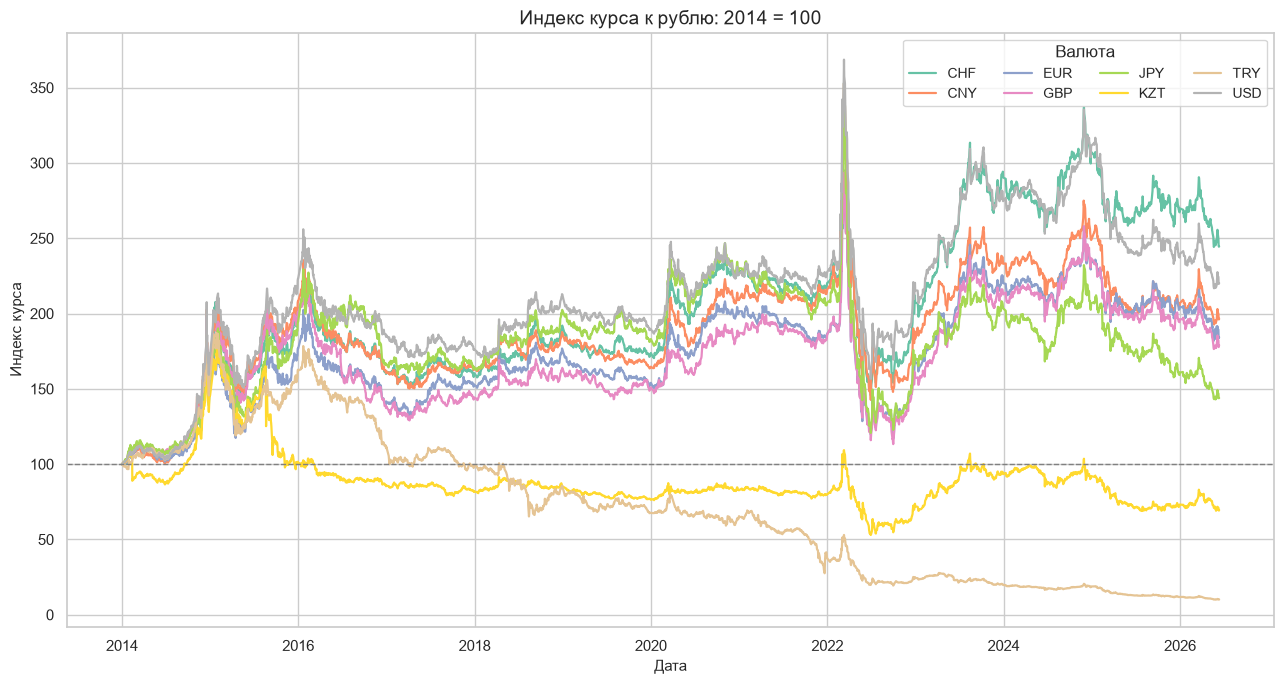

,char_code,currency_name,date,rate_rub,rate_index_2014
3066,CHF,Швейцарский франк,2026-06-12,89.885,244.509
24535,USD,Доллар США,2026-06-12,71.908,220.179
6133,CNY,Юань,2026-06-12,10.606,196.558
9200,EUR,Евро,2026-06-12,82.974,184.159
12267,GBP,Фунт стерлингов,2026-06-12,96.371,178.947
15334,JPY,Иена,2026-06-12,0.448,143.917
18401,KZT,Тенге,2026-06-12,0.147,69.500
21468,TRY,Турецкая лира,2026-06-12,1.560,10.125


In [6]:
# Рисуем общую траекторию валют за весь период
fig, ax = plt.subplots(figsize=(13, 7))
sns.lineplot(
    data=rates,
    x="date",
    y="rate_index_2014",
    hue="char_code",
    linewidth=1.6,
    ax=ax,
)
ax.axhline(100, color="gray", linestyle="--", linewidth=1)
ax.set_title("Индекс курса к рублю: 2014 = 100")
ax.set_xlabel("Дата")
ax.set_ylabel("Индекс курса")
ax.legend(title="Валюта", ncol=4)
fig.tight_layout()
fig.savefig(FIGURES / "fig01_currency_index.png", dpi=200, bbox_inches="tight")
plt.show()

# Берем последнюю дату, чтобы ранжировать валюты по итоговому росту
latest_index = (
    rates.loc[rates.groupby("char_code")["date"].idxmax()]
    [["char_code", "currency_name", "date", "rate_rub", "rate_index_2014"]]
    .sort_values("rate_index_2014", ascending=False)
)
display(latest_index)

### Промежуточный вывод

По индексу с 2014 года сильнее всего вырос CHF, а слабее всего выглядит TRY. Это не означает, что рубль одинаково слабел ко всем валютам: часть валют сама проходила через сильную девальвацию, поэтому итоговая динамика зависит сразу от двух сторон валютной пары.

На графике видно, что валюты разделились на несколько траекторий. CHF, USD, CNY, EUR и GBP укрепились к рублю относительно начала 2014 года. TRY и KZT, наоборот, сильно снизились относительно рубля, потому что их собственная девальвация была сильнее рублевой.

## 6. Годовая динамика и волатильность

Сравним годы по доходности, диапазону движения и годовой волатильности.

Здесь анализ переходит с дневного уровня на годовой. Это удобно для поиска периодов турбулентности: отдельный дневной скачок может быть случайностью, а высокий годовой показатель волатильности уже говорит о длительном нестабильном периоде.

,char_code,year,annualized_volatility_pct,annual_return_pct,rate_range_pct,extreme_return_days
60,JPY,2022,42.006,-18.263,176.493,24
34,EUR,2022,41.103,-11.131,152.111,24
47,GBP,2022,41.006,-16.906,159.493,28
66,KZT,2015,40.991,-30.174,84.433,6
8,CHF,2022,40.389,-6.594,142.515,18
21,CNY,2022,39.973,-16.079,147.342,25
99,USD,2022,39.970,-6.381,135.307,24
86,TRY,2022,39.414,-30.820,173.440,21
73,KZT,2022,38.139,-11.458,106.361,24
85,TRY,2021,37.480,-42.142,151.283,12


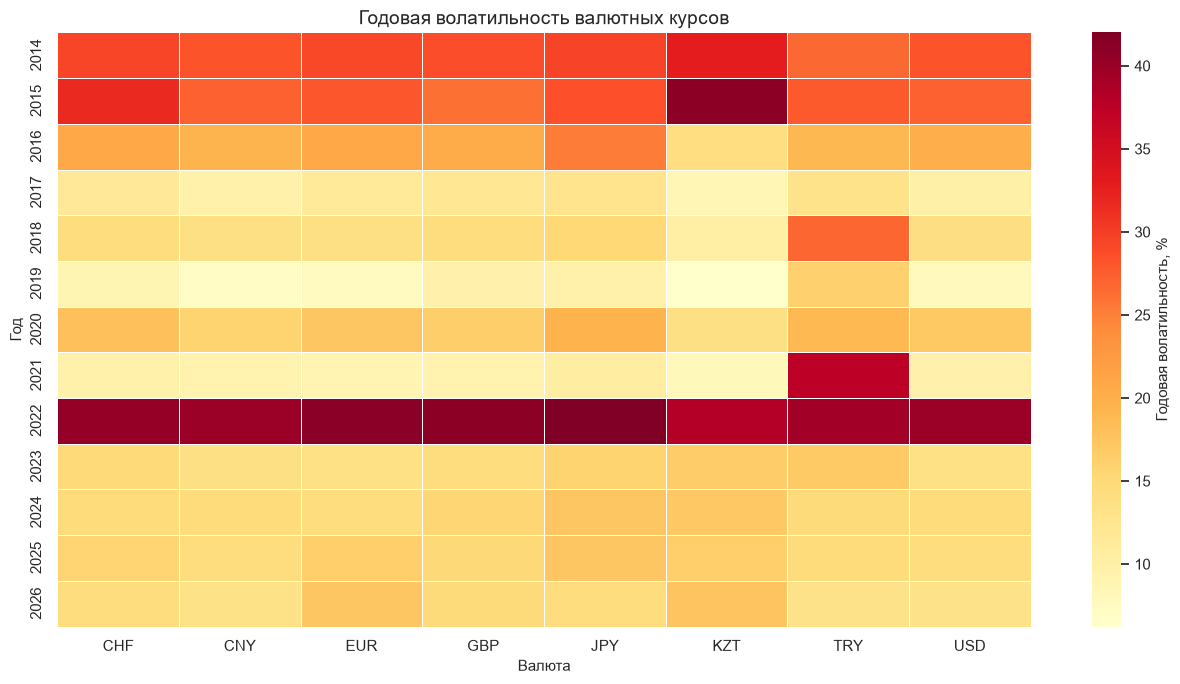

In [7]:
# Сначала ищем самые нервные годы
annual_top_volatility = (
    annual.sort_values("annualized_volatility_pct", ascending=False)
    [[
        "char_code",
        "year",
        "annualized_volatility_pct",
        "annual_return_pct",
        "rate_range_pct",
        "extreme_return_days",
    ]]
    .head(12)
)
display(annual_top_volatility)

# Для heatmap разворачиваем годы в строки, валюты в столбцы
annual_volatility_pivot = annual.pivot_table(
    index="year",
    columns="char_code",
    values="annualized_volatility_pct",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    annual_volatility_pivot,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Годовая волатильность, %"},
    ax=ax,
)
ax.set_title("Годовая волатильность валютных курсов")
ax.set_xlabel("Валюта")
ax.set_ylabel("Год")
fig.tight_layout()
fig.savefig(FIGURES / "fig02_annual_volatility_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

Максимальная годовая волатильность в выборке наблюдается у JPY в 2022 году. При этом сам 2022 год выделяется не только для одной валюты: на тепловой карте видно, что общий уровень волатильности вырос сразу по нескольким валютным парам.

Поэтому 2022 год можно рассматривать как общий рыночный шок, а не как частный случай одной валюты. Это важный аргумент для дальнейшего сравнения спокойного и шокового периодов.

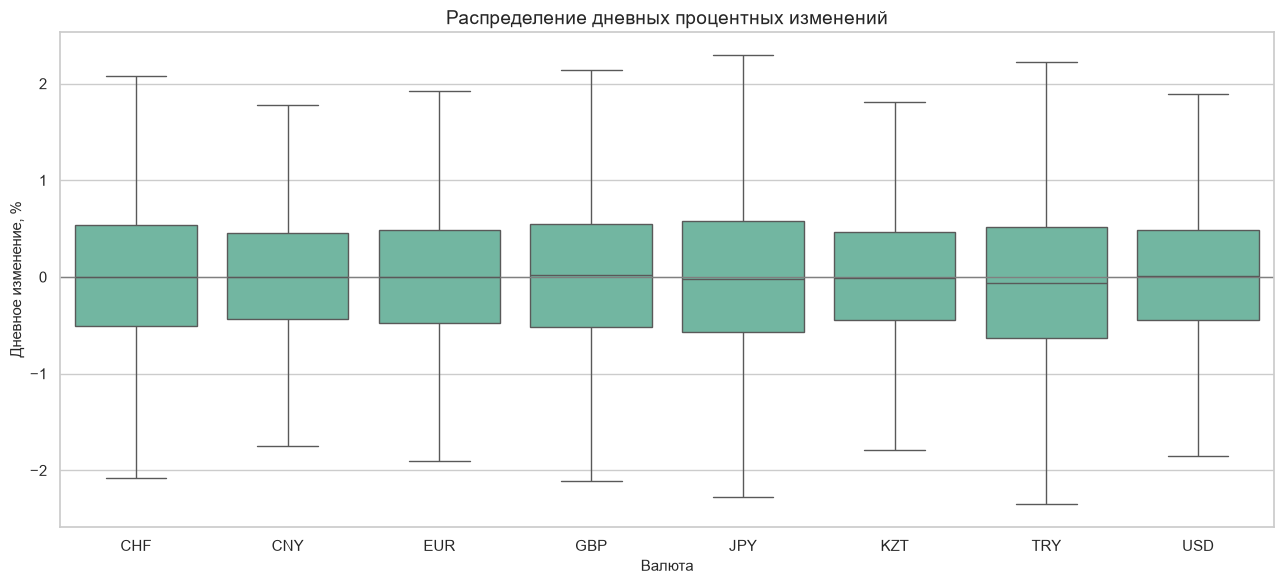

In [8]:
# Boxplot показывает медиану и типичный разброс дневных изменений
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=rates.dropna(subset=["daily_return_pct"]),
    x="char_code",
    y="daily_return_pct",
    order=sorted(rates["char_code"].unique()),
    showfliers=False,
    ax=ax,
)
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Распределение дневных процентных изменений")
ax.set_xlabel("Валюта")
ax.set_ylabel("Дневное изменение, %")
fig.tight_layout()
fig.savefig(FIGURES / "fig03_daily_return_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

Boxplot показывает, что у TRY самый широкий типичный разброс дневных изменений. Это подтверждает вывод из таблицы экстремальных дней: TRY отличается не только отдельными всплесками, но и более нервным повседневным поведением.

Период 2022 года выделяется почти по всем валютам: в этот год наблюдаются самые высокие значения годовой волатильности. Это подтверждает, что экстремальные значения не являются случайным шумом отдельной валюты, а отражают общий рыночный шок.

## 7. Корреляции дневных изменений

Для корреляционного анализа используем логарифмические доходности, а не сами уровни курсов. Уровни временных рядов часто имеют общий тренд, который может завышать корреляцию.

Коэффициент Спирмена выбран как основной для визуальной матрицы, потому что он устойчивее к нелинейности и выбросам, чем корреляция Пирсона. Для отдельных пар ниже считаются оба коэффициента.

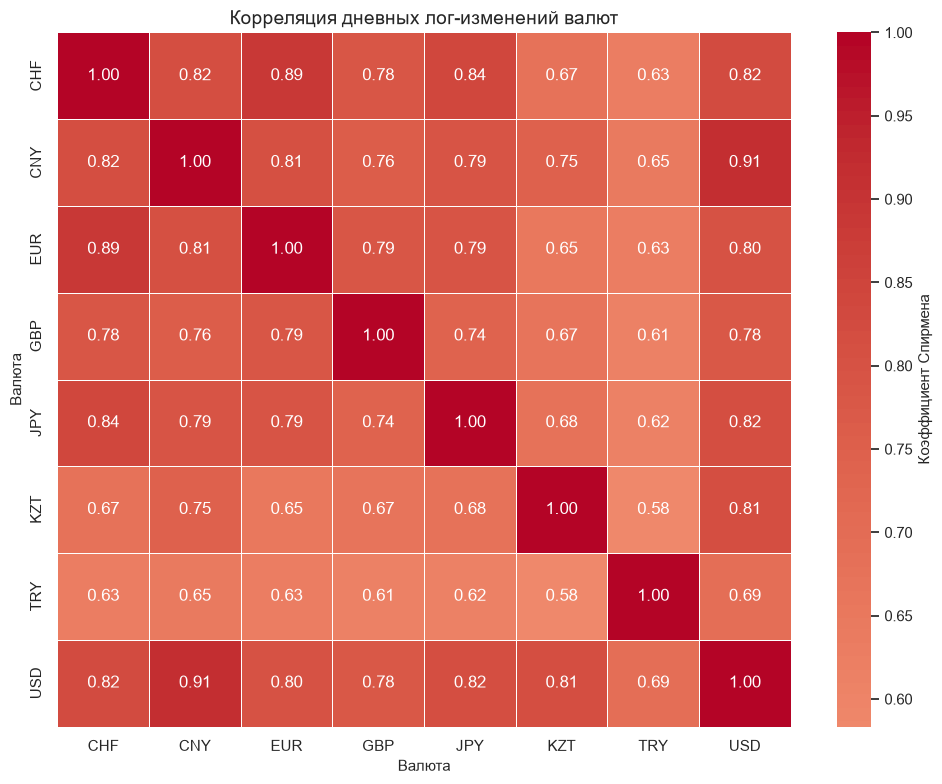

In [9]:
# Делаем широкий формат: дата в строке, валюты в столбцах
returns_wide = rates.pivot(index="date", columns="char_code", values="log_return").dropna()
corr_spearman = returns_wide.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Коэффициент Спирмена"},
    ax=ax,
)
ax.set_title("Корреляция дневных лог-изменений валют")
ax.set_xlabel("Валюта")
ax.set_ylabel("Валюта")
fig.tight_layout()
fig.savefig(FIGURES / "fig04_return_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

Большинство валют имеют положительные корреляции дневных изменений. Это означает, что в данных видна общая рублевая компонента: когда рубль резко меняется, несколько валютных пар часто реагируют в одном направлении.

При этом корреляции не равны единице, значит у каждой валюты остается собственная динамика. Именно поэтому дальше полезно проверять отдельные пары и делать кластеризацию.

In [10]:
# Для H1 берем несколько пар, которые легко объяснить
pairs = [("USD", "EUR"), ("USD", "CNY"), ("USD", "TRY"), ("EUR", "GBP")]
corr_tests = []

for left, right in pairs:
    x = returns_wide[left]
    y = returns_wide[right]
    # Пирсон: линейная связь, Спирмен: общий порядок движений
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    corr_tests.append(
        {
            "pair": f"{left}-{right}",
            "pearson_r": pearson_r,
            "pearson_p_value": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p_value": spearman_p,
        }
    )

corr_tests = pd.DataFrame(corr_tests)
display(corr_tests)

,pair,pearson_r,pearson_p_value,spearman_r,spearman_p_value
0,USD-EUR,0.914,0.000,0.799,0.000
1,USD-CNY,0.956,0.000,0.915,0.000
2,USD-TRY,0.718,0.000,0.690,0.000
3,EUR-GBP,0.896,0.000,0.787,0.000


### Вывод по H1

Гипотеза H1 подтверждается: дневные движения USD/RUB и EUR/RUB сильно и статистически значимо связаны. Коэффициент Спирмена для пары USD-EUR равен примерно 0.799, а p-value практически равно нулю, поэтому положительная связь не выглядит случайной.

Это логично экономически: обе валюты измеряют движение рубля относительно крупных внешних валют, поэтому в периоды общего ослабления или укрепления рубля они часто движутся синхронно. При этом связь не идеальная, потому что на EUR/RUB дополнительно влияет динамика EUR/USD.

## 8. Проверка гипотезы о росте волатильности USD/RUB

Сравним абсолютные дневные изменения USD/RUB в двух периодах:

- 2017-2019: относительно спокойный период;
- 2022-2023: период резкого рыночного шока и адаптации.

Перед сравнением периодов проверим форму распределений тестом Шапиро-Уилка на подвыборке.

Нулевая гипотеза теста Шапиро-Уилка: распределение похоже на нормальное. Если p-value маленькое, нормальность отвергается, поэтому обычный t-test здесь лучше не делать основной проверкой.

Тест Шапиро-Уилка можно использовать, но на больших выборках он становится очень чувствительным даже к небольшим отклонениям от нормальности. Поэтому здесь берется подвыборка до 500 наблюдений из каждого периода: этого достаточно для проверки формы распределения и не создает лишней чувствительности теста.

Используем простую OLS-регрессию через `statsmodels`: объясняем абсолютное дневное изменение бинарным признаком `shock_period`, где `1` - 2022-2023 годы, а `0` - 2017-2019 годы. Коэффициент при `shock_period` показывает, на сколько процентных пунктов в среднем выросла дневная волатильность в шоковый период.

,period_group,n,mean_abs_daily_return_pct,median_abs_daily_return_pct,std_abs_daily_return_pct,shapiro_p_value
0,2017-2019,740,0.483,0.358,0.498,0.000
1,2022-2023,494,1.067,0.538,1.579,0.000


,coef,p_value,ci_low,ci_high
const,0.483,0.000,0.406,0.561
shock_period,0.584,0.000,0.462,0.706


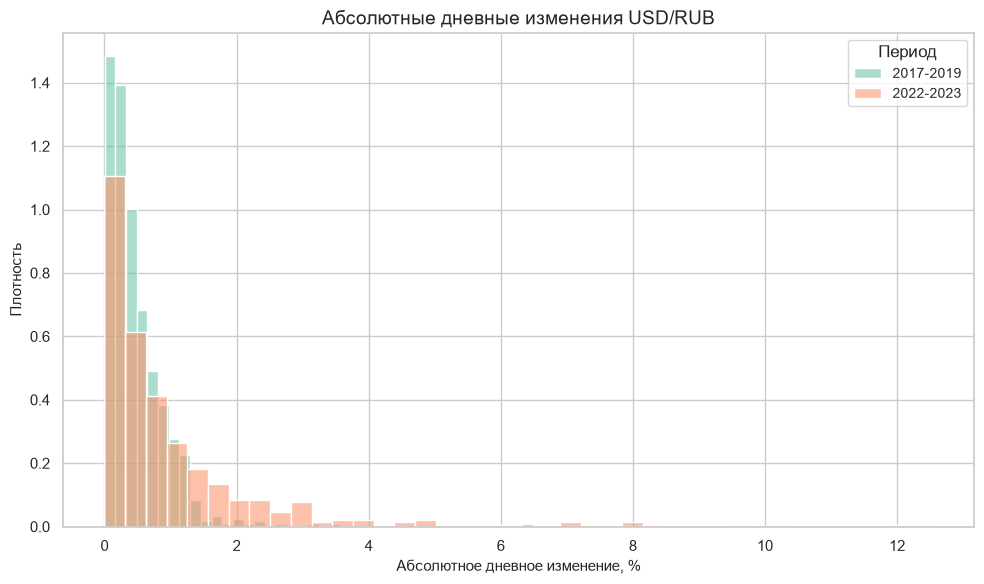

In [11]:
# Берем модуль изменения, потому что важен размер скачка
usd_returns = rates.query("char_code == 'USD'").dropna(subset=["daily_return_pct"]).copy()
usd_returns["abs_daily_return_pct"] = usd_returns["daily_return_pct"].abs()

# Делим USD/RUB на спокойный и шоковый периоды
calm_period = usd_returns.query("2017 <= year <= 2019").copy()
shock_period = usd_returns.query("2022 <= year <= 2023").copy()
calm_period["period_group"] = "2017-2019"
shock_period["period_group"] = "2022-2023"
calm_period["shock_period"] = 0
shock_period["shock_period"] = 1

period_returns = pd.concat([calm_period, shock_period], ignore_index=True)

calm = calm_period["abs_daily_return_pct"]
shock = shock_period["abs_daily_return_pct"]

# Для Шапиро берем подвыборку, чтобы тест не был чрезмерно чувствительным
calm_sample = calm.sample(min(500, len(calm)), random_state=42)
shock_sample = shock.sample(min(500, len(shock)), random_state=42)

shapiro_calm = stats.shapiro(calm_sample)
shapiro_shock = stats.shapiro(shock_sample)

period_summary = (
    period_returns.groupby("period_group")
    .agg(
        n=("abs_daily_return_pct", "size"),
        mean_abs_daily_return_pct=("abs_daily_return_pct", "mean"),
        median_abs_daily_return_pct=("abs_daily_return_pct", "median"),
        std_abs_daily_return_pct=("abs_daily_return_pct", "std"),
    )
    .reset_index()
)
period_summary["shapiro_p_value"] = [
    shapiro_calm.pvalue,
    shapiro_shock.pvalue,
]
display(period_summary)

# Через OLS коэффициент shock_period равен разнице средних между периодами
X_period = sm.add_constant(period_returns[["shock_period"]])
y_period = period_returns["abs_daily_return_pct"]
volatility_model = sm.OLS(y_period, X_period).fit()
volatility_effect = pd.DataFrame(
    {
        "coef": volatility_model.params,
        "p_value": volatility_model.pvalues,
        "ci_low": volatility_model.conf_int()[0],
        "ci_high": volatility_model.conf_int()[1],
    }
)
display(volatility_effect)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(calm, bins=40, stat="density", alpha=0.55, label="2017-2019", ax=ax)
sns.histplot(shock, bins=40, stat="density", alpha=0.55, label="2022-2023", ax=ax)
ax.set_title("Абсолютные дневные изменения USD/RUB")
ax.set_xlabel("Абсолютное дневное изменение, %")
ax.set_ylabel("Плотность")
ax.legend(title="Период")
fig.tight_layout()
fig.savefig(FIGURES / "fig05_usd_volatility_periods.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

Среднее абсолютное дневное изменение USD/RUB выросло с 0.483% в спокойный период до 1.067% в шоковый период. По OLS разница составляет около 0.584 процентного пункта, а p-value крайне мал, то есть эффект статистически значим.

Оба распределения не похожи на нормальные, поэтому простой t-test не используется как основной аргумент. Вместо этого сравнение оформлено через OLS-модель с бинарным признаком периода.

Коэффициент при `shock_period` положительный и значимый, значит гипотеза H2 подтверждается: в 2022-2023 годах абсолютные дневные изменения USD/RUB выше, чем в 2017-2019 годах.

## 9. Макрообогащение годовой сводки

Из World Bank API добавлены годовая инфляция, рост ВВП и официальный среднегодовой курс. Эти данные не являются дневными факторами, но помогают связать валютную динамику с макроэкономическим контекстом.

Задача - показать, как годовые валютные показатели выглядят рядом с инфляцией и ростом ВВП.

,year,mean_rate_rub,annual_return_pct,annualized_volatility_pct,inflation_consumer_prices_pct,gdp_growth_pct,official_exchange_rate_lcu_per_usd
91,2014,38.602,72.262,28.307,7.820,0.736,38.378
92,2015,61.319,29.598,27.284,15.534,-1.973,60.938
93,2016,66.833,-16.828,20.202,7.042,0.194,67.056
94,2017,58.298,-3.833,10.120,3.683,1.826,58.343
95,2018,62.926,21.779,14.003,2.878,2.807,62.668
96,2019,64.618,-7.713,7.865,4.472,2.198,64.738
97,2020,72.323,19.336,17.185,3.382,-2.654,72.105
98,2021,73.669,0.564,9.593,6.694,5.866,73.654
99,2022,68.352,-6.381,39.970,13.744,-1.436,68.485
100,2023,85.812,27.579,13.600,5.866,4.083,85.162


,mean_rate_rub,annual_return_pct,annualized_volatility_pct,inflation_consumer_prices_pct,gdp_growth_pct,official_exchange_rate_lcu_per_usd
mean_rate_rub,1.000,-0.191,-0.209,0.055,0.418,1.000
annual_return_pct,-0.191,1.000,0.273,0.091,-0.027,-0.191
annualized_volatility_pct,-0.209,0.273,1.000,0.609,-0.664,-0.209
inflation_consumer_prices_pct,0.055,0.091,0.609,1.000,-0.173,0.055
gdp_growth_pct,0.418,-0.027,-0.664,-0.173,1.000,0.418
official_exchange_rate_lcu_per_usd,1.000,-0.191,-0.209,0.055,0.418,1.000


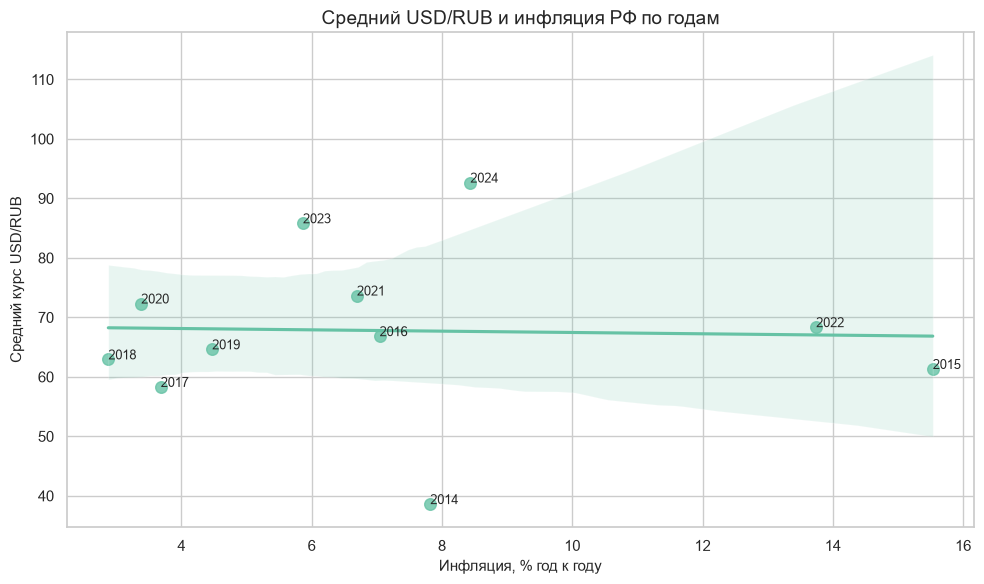

In [ ]:
# Берем USD, потому что макропоказатель World Bank тоже про курс к доллару
usd_annual = annual.query("char_code == 'USD'").copy()
usd_annual = usd_annual.dropna(
    subset=["inflation_consumer_prices_pct", "gdp_growth_pct"]
)

# Собираем компактную таблицу для годовой интерпретации
macro_view = usd_annual[
    [
        "year",
        "mean_rate_rub",
        "annual_return_pct",
        "annualized_volatility_pct",
        "inflation_consumer_prices_pct",
        "gdp_growth_pct",
        "official_exchange_rate_lcu_per_usd",
    ]
].sort_values("year")
display(macro_view)

# Спирмен тут уместнее: годовых точек мало и связь не обязана быть линейной
macro_corr = macro_view[
    [
        "mean_rate_rub",
        "annual_return_pct",
        "annualized_volatility_pct",
        "inflation_consumer_prices_pct",
        "gdp_growth_pct",
        "official_exchange_rate_lcu_per_usd",
    ]
].corr(method="spearman")
display(macro_corr)

# Подписываем годы
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=macro_view,
    x="inflation_consumer_prices_pct",
    y="mean_rate_rub",
    scatter_kws={"s": 70},
    ax=ax,
)
for _, row in macro_view.iterrows():
    ax.text(row["inflation_consumer_prices_pct"], row["mean_rate_rub"], int(row["year"]), fontsize=9)
ax.set_title("Средний USD/RUB и инфляция РФ по годам")
ax.set_xlabel("Инфляция, % год к году")
ax.set_ylabel("Средний курс USD/RUB")
fig.tight_layout()
fig.savefig(FIGURES / "fig06_macro_usd_inflation.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

На годовом уровне связь среднего USD/RUB с инфляцией по Спирмену равна примерно 0.055. Это почти нулевая связь, поэтому по этой выборке нельзя сказать, что инфляция напрямую объясняет средний курс доллара.

Макроданные дают осторожную интерпретацию: на малом числе годовых наблюдений нельзя доказывать причинность, но можно увидеть контекст. Годы с высокой инфляцией и высокой валютной волатильностью совпадают с периодами крупных внешних шоков, однако сам курс зависит от более широкого набора факторов.

## 10. Регрессионная модель для USD/RUB

Построим объяснительную линейную модель. Целевая переменная - курс USD/RUB, признаки - курсы других валют и временной индекс. Разбиение делается хронологически: последние 20% наблюдений остаются тестовой выборкой.

Важно: это не торговая прогнозная модель, потому что признаки берутся за тот же день. Ее задача - показать, насколько USD/RUB объясняется общей структурой валютных курсов.

`StandardScaler` обучается только на тренировочной части. Это защищает от data leakage, когда информация из тестового периода случайно попадает в обучение.

,metric,value
0,MAE,4.309
1,RMSE,5.349
2,R2,0.554


,feature,scaled_coefficient
3,CHF,10.276
1,CNY,5.056
6,TRY,2.518
7,time_index,2.166
2,GBP,-1.887
0,EUR,-1.582
4,JPY,0.787
5,KZT,-0.531


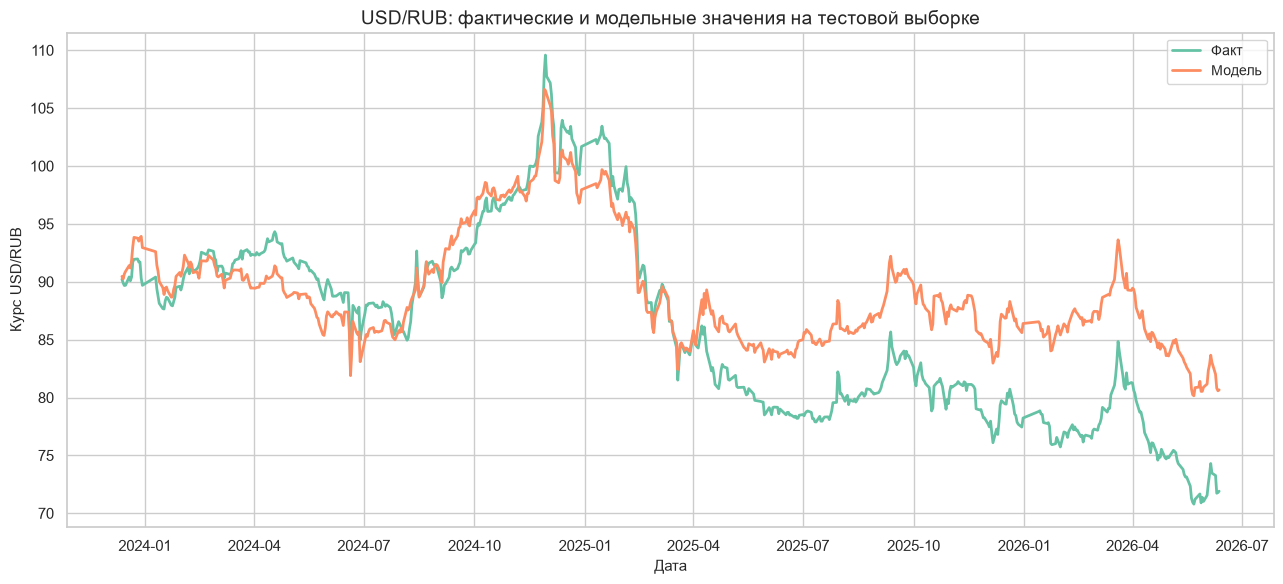

In [ ]:
# Делаем из валют отдельные признаки для модели
wide_rates = rates.pivot(index="date", columns="char_code", values="rate_rub").dropna()
wide_rates["time_index"] = np.arange(len(wide_rates))

target = wide_rates["USD"]
features = wide_rates[["EUR", "CNY", "GBP", "CHF", "JPY", "KZT", "TRY", "time_index"]]

# Не перемешиваем даты, чтобы обучаться на прошлом и проверяться на будущем
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    shuffle=False,
)

# Масштабируем признаки, иначе коэффициенты нельзя сравнивать
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Берем линейную регрессию
regression = LinearRegression()
regression.fit(X_train_scaled, y_train)
y_pred = regression.predict(X_test_scaled)

# MAE и RMSE: ошибка в рублях, R2: доля объясненной динамики
regression_metrics = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [
            mean_absolute_error(y_test, y_pred),
            np.sqrt(mean_squared_error(y_test, y_pred)),
            r2_score(y_test, y_pred),
        ],
    }
)
display(regression_metrics)

# После стандартизации коэффициенты можно сравнивать по модулю
coefficients = (
    pd.DataFrame(
        {
            "feature": features.columns,
            "scaled_coefficient": regression.coef_,
        }
    )
    .assign(abs_coef=lambda x: x["scaled_coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
)
display(coefficients)

# Для графика берем только тестовый период
prediction_frame = pd.DataFrame(
    {
        "date": y_test.index,
        "actual_usd_rub": y_test.values,
        "predicted_usd_rub": y_pred,
    }
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(prediction_frame["date"], prediction_frame["actual_usd_rub"], label="Факт", linewidth=2)
ax.plot(prediction_frame["date"], prediction_frame["predicted_usd_rub"], label="Модель", linewidth=2)
ax.set_title("USD/RUB: фактические и модельные значения на тестовой выборке")
ax.set_xlabel("Дата")
ax.set_ylabel("Курс USD/RUB")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "fig07_regression_actual_predicted.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

Модель улавливает часть общей валютной динамики: R2 на тестовой выборке равен примерно 0.554. Это означает, что линейная регрессия объясняет заметную долю изменения USD/RUB, но оставляет существенную часть движения вне модели.

Такой результат нормален для объяснительной модели валютного курса. В признаки не включены новости, ограничения рынка, изменение ставок и другие факторы, поэтому задача модели здесь не идеальный прогноз, а проверка того, насколько USD/RUB встроен в общую структуру валютных курсов.

In [14]:
# VIF показывает, насколько признаки дублируют друг друга
vif_table = pd.DataFrame(
    {
        "feature": features.columns,
        "VIF": [
            variance_inflation_factor(features.values, i)
            for i in range(features.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)
display(vif_table)

# statsmodels нужен для p-value и доверительных интервалов
X_train_for_ols = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_for_ols).fit()
ols_table = pd.DataFrame(
    {
        "coef": ols_model.params,
        "p_value": ols_model.pvalues,
        "ci_low": ols_model.conf_int()[0],
        "ci_high": ols_model.conf_int()[1],
    }
)
display(ols_table)

,feature,VIF
0,EUR,"1,733.124"
2,GBP,"1,409.292"
1,CNY,"1,068.449"
3,CHF,949.059
4,JPY,350.035
7,time_index,70.184
5,KZT,62.097
6,TRY,29.239


,coef,p_value,ci_low,ci_high
const,0.216,0.613,-0.622,1.055
EUR,-0.117,0.000,-0.154,-0.080
CNY,2.784,0.000,2.539,3.029
GBP,-0.123,0.000,-0.149,-0.096
CHF,0.679,0.000,0.650,0.707
JPY,7.477,0.000,5.239,9.715
KZT,-12.849,0.000,-15.984,-9.714
TRY,0.388,0.000,0.346,0.430
time_index,0.003,0.000,0.003,0.004


### Промежуточный вывод

Самый высокий VIF у признака EUR, значение около 1733.1. Это очень высокий показатель мультиколлинеарности: часть признаков сильно дублирует друг друга, потому что крупные валюты часто движутся синхронно относительно рубля.

Модель показывает умеренное качество на отложенном периоде, но из-за высокого VIF отдельные коэффициенты нужно интерпретировать осторожно. Модель полезна как объяснительная демонстрация общей валютной структуры, но коэффициенты нельзя читать как независимое влияние каждой валюты.

## 11. Кластеризация валют по поведению

Для кластеризации создадим таблицу признаков по каждой валюте:

- итоговое изменение курса с 2014 года;
- средняя абсолютная дневная доходность;
- годовая волатильность;
- доля экстремальных дней;
- корреляция дневных изменений с USD/RUB.

Кластеризация здесь нужна для сегментации, чтобы определить какие валюты похожи по поведению за весь период наблюдений.

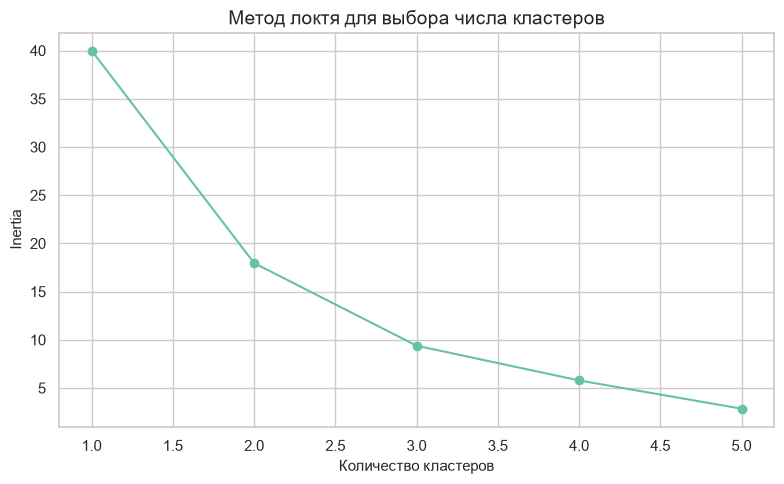

,char_code,currency_name,cluster,total_return_pct,mean_abs_daily_return_pct,annualized_volatility_pct,extreme_share_pct,spearman_corr_with_usd
5,KZT,Тенге,0,-30.500,0.761,21.688,1.630,0.815
4,JPY,Иена,0,43.917,0.881,21.986,1.565,0.819
3,GBP,Фунт стерлингов,0,78.947,0.807,20.442,1.663,0.782
2,EUR,Евро,0,84.159,0.784,20.638,1.761,0.799
0,CHF,Швейцарский франк,0,144.509,0.816,21.131,1.598,0.822
6,TRY,Турецкая лира,1,-89.875,0.905,23.948,1.924,0.690
1,CNY,Юань,2,96.558,0.735,19.807,1.630,0.915
7,USD,Доллар США,2,120.179,0.754,20.020,1.532,1.000


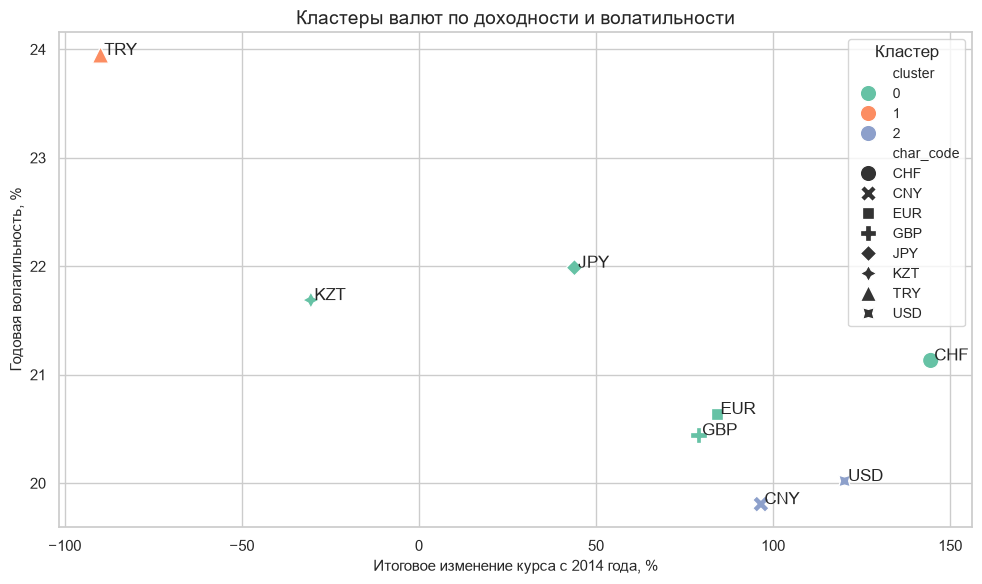

In [ ]:
# Собираем одну строку признаков на каждую валюту
currency_features = (
    rates.groupby(["char_code", "currency_name"])
    .agg(
        start_rate=("rate_rub", "first"),
        end_rate=("rate_rub", "last"),
        mean_abs_daily_return_pct=("daily_return_pct", lambda x: x.abs().mean()),
        annualized_volatility_pct=("log_return", lambda x: x.dropna().std() * np.sqrt(252) * 100),
        extreme_share_pct=("extreme_return", lambda x: x.mean() * 100),
    )
    .reset_index()
)
# Итоговая доходность показывает изменение за весь период
currency_features["total_return_pct"] = (
    currency_features["end_rate"] / currency_features["start_rate"] - 1
) * 100

# Корреляция с USD показывает синхронность с главным ориентиром
usd_correlations = returns_wide.corr(method="spearman")["USD"].rename("spearman_corr_with_usd")
currency_features = currency_features.merge(
    usd_correlations.reset_index().rename(columns={"index": "char_code"}),
    on="char_code",
    how="left",
)

cluster_columns = [
    "total_return_pct",
    "mean_abs_daily_return_pct",
    "annualized_volatility_pct",
    "extreme_share_pct",
    "spearman_corr_with_usd",
]

# Масштабируем признаки, иначе KMeans будет смотреть только на крупные числа
X_cluster = currency_features[cluster_columns].fillna(0)
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Метод локтя помогает не брать число кластеров наугад
inertias = []
k_values = range(1, 6)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Метод локтя для выбора числа кластеров")
ax.set_xlabel("Количество кластеров")
ax.set_ylabel("Inertia")
fig.tight_layout()
fig.savefig(FIGURES / "fig08_kmeans_elbow.png", dpi=200, bbox_inches="tight")
plt.show()

# Берем 3 кластера
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
currency_features["cluster"] = kmeans.fit_predict(X_cluster_scaled)

display(
    currency_features.sort_values(["cluster", "total_return_pct"])[
        ["char_code", "currency_name", "cluster"] + cluster_columns
    ]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=currency_features,
    x="total_return_pct",
    y="annualized_volatility_pct",
    hue="cluster",
    style="char_code",
    s=140,
    palette="Set2",
    ax=ax,
)
for _, row in currency_features.iterrows():
    ax.text(row["total_return_pct"] + 1, row["annualized_volatility_pct"], row["char_code"])
ax.set_title("Кластеры валют по доходности и волатильности")
ax.set_xlabel("Итоговое изменение курса с 2014 года, %")
ax.set_ylabel("Годовая волатильность, %")
ax.legend(title="Кластер")
fig.tight_layout()
fig.savefig(FIGURES / "fig09_currency_clusters.png", dpi=200, bbox_inches="tight")
plt.show()

### Промежуточный вывод

KMeans разделил валюты на группы размером `{0: 5, 1: 1, 2: 2}`. Такой результат удобен для содержательной сегментации: часть валют попадает в общий кластер, а отдельные валюты выделяются из-за собственной нестабильности или сильной девальвации.

**Кластер 0: CHF, EUR, GBP, JPY, KZT.** Это самый большой кластер. Валюты в нем имеют среднюю связь с USD/RUB и похожий уровень волатильности. Внутри группы есть разные итоговые доходности, но по набору признаков они ближе друг к другу, чем к TRY или паре USD-CNY.

**Кластер 1: TRY.** Турецкая лира выделилась в отдельный кластер из-за самой сильной отрицательной итоговой доходности, высокой волатильности и повышенной доли экстремальных дней. Это валюта с выраженной собственной девальвацией, поэтому она хуже похожа на остальные валюты выборки.

**Кластер 2: CNY, USD.** Юань и доллар попали в один кластер из-за высокой синхронности с USD/RUB, сравнительно меньшей волатильности и похожей итоговой траектории роста к рублю. Этот кластер можно интерпретировать как наиболее близкий к основной долларовой динамике.

Кластеризация показывает, что валюты с похожей реакцией на рублевые шоки группируются вместе, а TRY и KZT выделяются из-за сильной собственной девальвации. Это хороший пример того, почему анализировать только USD/RUB недостаточно: разные валюты отражают не только состояние рубля, но и собственные страновые факторы.

## 12. Итоговые выводы

1. За период 2014-2026 годов большинство выбранных валют укрепились к рублю. Наиболее заметный рост индекса показали CHF и USD; TRY и KZT, наоборот, снизились относительно рубля из-за собственной девальвации.

2. Самый волатильный общий период - 2022 год. Это видно по годовой волатильности, экстремальным дневным изменениям и распределению дневных доходностей.

3. Дневные изменения USD/RUB и EUR/RUB положительно и статистически значимо связаны. Это подтверждает гипотезу о сильной общей рублевой компоненте в движении крупных валют.

4. Абсолютные дневные изменения USD/RUB в 2022-2023 годах выше, чем в 2017-2019 годах. Для проверки использована OLS-регрессия с бинарным признаком `shock_period`; коэффициент положительный и статистически значимый.

5. Линейная модель частично объясняет USD/RUB через другие валютные курсы и временной индекс, но высокая мультиколлинеарность ограничивает интерпретацию отдельных коэффициентов.

6. Кластеризация валют показывает разные типы поведения: крупные резервные валюты, валюты с сильной собственной девальвацией и промежуточные случаи.

Практическая ценность анализа состоит в том, что он помогает оценить риск: какие валюты движутся синхронно, где были всплески волатильности и почему валютная корзина дает больше информации, чем один курс USD/RUB.